In [1]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
from utilsCPD import *
import matplotlib.pyplot as plt
from SWCPD import BaseDetector as SWDCP
import time


BATCH_SIZE  =32
mnist_transforms = transforms.Compose([transforms.ToTensor()])
train_val_dataset = datasets.MNIST(root="./datasets/", train=True, download=True, transform=mnist_transforms)
test_dataset = datasets.MNIST(root="./datasets/", train=False, download=True, transform=mnist_transforms)
train_size = int(0.9 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset=train_val_dataset, lengths=[train_size, val_size])
train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True)

all_batches = []
all_labels =[]
torch.manual_seed(10)
for x,y in test_dataloader:
    bs = x.shape[0]
    all_batches.append(x.flatten().reshape(bs,784))
    all_labels.append(y)

all_batches = torch.cat(all_batches,dim=0)
all_labels = torch.cat(all_labels,dim=0)

print(all_batches.shape)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.43MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 264kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.32MB/s]


torch.Size([10000, 784])


In [7]:
Labels_Sampled = []
seed = 2
rng = np.random.default_rng(seed)


def sample_classes(seed,n_classes = 1,nb_experiments=5):
    rng = np.random.default_rng(seed)
    Labels_Sampled = []
    for run in range(nb_experiments):
        l = tuple(rng.choice(np.arange(10),n_classes,replace=False))
        if l not in Labels_Sampled:
            Labels_Sampled.append(l)
    return Labels_Sampled

Labels_Sampled = sample_classes(seed=seed, n_classes=2,nb_experiments=5)

print(Labels_Sampled)
def FilterData(all_batches,all_labels,lables,N_Samples=1000):
    data = []
    cps = []
    for l in lables:
        d =all_batches[all_labels==l].detach().numpy()
        data.append(d[:N_Samples])
        cps.append(len(d[:N_Samples]))
    return np.vstack(data),np.cumsum(cps)[:-1]


FilterData(all_batches,all_labels,list(Labels_Sampled[0]))


[(np.int64(2), np.int64(7)), (np.int64(2), np.int64(4)), (np.int64(0), np.int64(4)), (np.int64(5), np.int64(8)), (np.int64(8), np.int64(1))]


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(2000, 784), dtype=float32),
 array([1000]))

In [15]:
all_labels.unique().numpy()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [18]:
def generate_null_data(X,y,N=500):
    return [np.vstack(X[y==label][:N].numpy()) for label in y.unique().numpy() ]


In [20]:
NULL_DATA = generate_null_data(all_batches,all_labels)

In [26]:
significance_values = [0.01, 0.05, 0.1, 0.15, 0.2]

METRICS_SWD = {}
METRICS_SWD_5 = {}
METRICS_SWD_10 = {}
METRICS_SWD_15 = {}
METRICS_SWD_30 = {}

Data_OUT = {}

for significance in significance_values:
    print(f"\nRunning significance = {significance}")

    METRICS_SWD[significance] = {}
    METRICS_SWD_5[significance] = {}
    METRICS_SWD_10[significance] = {}
    METRICS_SWD_15[significance] = {}
    METRICS_SWD_30[significance] = {}

    for id, df in enumerate(NULL_DATA):
        print(id)

        if id not in Data_OUT:
            Data_OUT[id] = {}

        GroundTruth = {}

        Data_OUT[id]["data"] = df
        Data_OUT[id]["target"] = GroundTruth

        print(GroundTruth)
        print(df.shape)

        detector = SWDCP(
            data=df,
            window_length=50,
            max_history=25,
            significance=significance
        )

        print(detector.device)

        start_time = time.time()
        detector.process_dataloader(
            p=4,
            n_theta=5000,
            seed=2025
        )
        end_time = time.time()

        runtime = end_time - start_time

        # Evaluation with threshold/window 20
        f1, covering_score, auc_score, fp, delay = detector.evaluate(GroundTruth, 20)

        METRICS_SWD[significance][id] = {
            "F1": f1,
            "Covering": covering_score,
            "AUC": auc_score,
            "DD": delay[1],
            "FP": fp,
            "RunTime": runtime,
            "significance": significance
        }

        # Evaluation with threshold/window 5
        f1, covering_score, auc_score, fp, delay = detector.evaluate(GroundTruth, 5)
        METRICS_SWD_5[significance][id] = {
            "AUC": auc_score,
            "FP": fp,
            "significance": significance
        }

        # Evaluation with threshold/window 10
        f1, covering_score, auc_score, fp, delay = detector.evaluate(GroundTruth, 10)
        METRICS_SWD_10[significance][id] = {
            "AUC": auc_score,
            "FP": fp,
            "significance": significance
        }

        # Evaluation with threshold/window 15
        f1, covering_score, auc_score, fp, delay = detector.evaluate(GroundTruth, 15)
        METRICS_SWD_15[significance][id] = {
            "AUC": auc_score,
            "FP": fp,
            "significance": significance
        }

        # Evaluation with threshold/window 30
        f1, covering_score, auc_score, fp, delay = detector.evaluate(GroundTruth, 30)
        METRICS_SWD_30[significance][id] = {
            "AUC": auc_score,
            "FP": fp,
            "significance": significance
        }

        print(METRICS_SWD[significance][id])


Running significance = 0.01
0
{}
(500, 784)
cuda


100%|██████████| 451/451 [00:05<00:00, 82.15it/s]


{0}
{0}
{0}
{0}
{0}
{'F1': 1.0, 'Covering': 1.0, 'AUC': 1.0, 'DD': 0, 'FP': 0, 'RunTime': 5.4975905418396, 'significance': 0.01}
1
{}
(500, 784)
cuda


100%|██████████| 451/451 [00:05<00:00, 83.99it/s]


{0}
{0}
{0}
{0}
{0}
{'F1': 1.0, 'Covering': 1.0, 'AUC': 1.0, 'DD': 0, 'FP': 0, 'RunTime': 5.376186847686768, 'significance': 0.01}
2
{}
(500, 784)
cuda


...

Change detected at: 326 
Initiate new segment


Change detected at: 416 
Initiate new segment
Change detected at: 427 
Initiate new segment


Change detected at: 475 
Initiate new segment


100%|██████████| 451/451 [00:05<00:00, 82.90it/s]

Change detected at: 496 
Initiate new segment
{0}
{0}
{0}
{0}
{0}
{'F1': 0.10526315789473684, 'Covering': 0.18, 'AUC': 0.5277777777777778, 'DD': 0, 'FP': 17, 'RunTime': 5.446628093719482, 'significance': 0.2}


In [30]:
import pandas as pd

rows = []

for significance, results_by_id in METRICS_SWD.items():
    for dataset_id, metrics in results_by_id.items():
        rows.append({
            "significance": significance,
            "dataset_id": dataset_id,
            "FP": metrics["FP"]
        })

fp_df = pd.DataFrame(rows)

fp_summary = (
    fp_df
    .groupby("significance")["FP"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

fp_summary


,significance,mean,std,min,max,count
0,0.01,0.0,0.000000,0,0,10
1,0.05,0.0,0.000000,0,0,10
2,0.10,0.7,1.059350,0,3,10
3,0.15,4.8,5.827140,0,20,10
4,0.20,16.2,11.103553,2,43,10


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Build dataframe from METRICS_SWD
rows = []

for significance, results_by_id in METRICS_SWD.items():
    for dataset_id, metrics in results_by_id.items():
        rows.append({
            "significance": significance,
            "confidence": 1 - significance,
            "dataset_id": dataset_id,
            "FP": metrics["FP"]
        })

fp_df = pd.DataFrame(rows)

# Aggregate FP over all datasets
fp_summary = (
    fp_df
    .groupby("confidence")["FP"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={
        "mean": "FP_mean",
        "std": "FP_std"
    })
)

# Sort in reverse order: 0.99, 0.95, 0.90, 0.85, 0.80
fp_summary = fp_summary.sort_values("confidence", ascending=False)

# In case std is NaN, e.g. only one dataset
fp_summary["FP_std"] = fp_summary["FP_std"].fillna(0)

fp_summary

,confidence,FP_mean,FP_std
4,0.99,0.0,0.000000
3,0.95,0.0,0.000000
2,0.90,0.7,1.059350
1,0.85,4.8,5.827140
0,0.80,16.2,11.103553


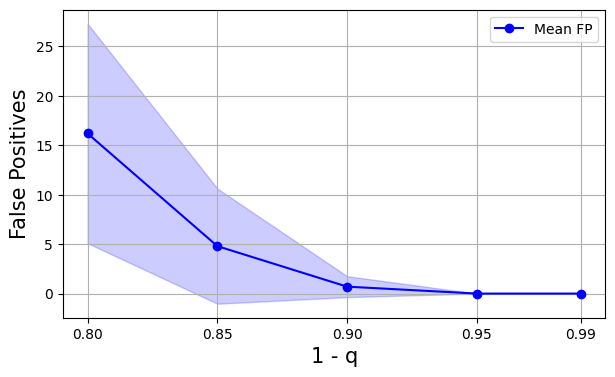

In [63]:
fig = plt.figure(figsize=(7, 4))

fp_summary = fp_summary.sort_values("confidence", ascending=True)
import matplotlib.pyplot as plt

# Sort so x-axis goes 0.80, 0.85, 0.90, 0.95, 0.99
fp_summary = fp_summary.sort_values("confidence", ascending=True)

x = fp_summary["confidence"]
y = fp_summary["FP_mean"]
std = fp_summary["FP_std"]


plt.plot(
    x,
    y,
    marker="o",
    label="Mean FP",color='blue'
)

plt.fill_between(
    x,
    y - std,
    y + std,
    alpha=0.2,
    #label="±1 std",
    color='blue'
)

plt.xlabel("1 - q",size=15)
plt.xticks(x)
plt.ylabel("False Positives",size=15)
#plt.title("False Positives Control",size=15)
plt.grid(True)
plt.legend()

plt.show();

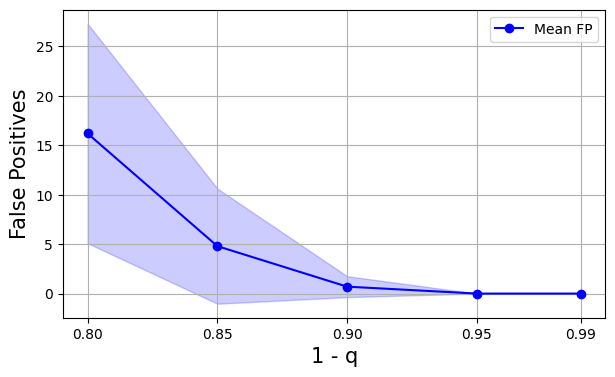

In [64]:
fig

In [67]:
fig.savefig('NULL_Controll.pdf',bbox_inches='tight')

In [ ]:
plt.savefig()

In [33]:
[1- q for q in significance_values]

[0.99, 0.95, 0.9, 0.85, 0.8]

In [25]:
METRICS_SWD = {}
METRICS_SWD_5 = {}
METRICS_SWD_10 = {}
METRICS_SWD_15 = {}
METRICS_SWD_30 = {}

Data_OUT = {}

for id,i in enumerate(range(len(NULL_DATA))):
    print(id)
    Data_OUT[id] = {}
    METRICS_SWD[id]  = {}
    METRICS_SWD_5[id] = {}
    METRICS_SWD_10[id] = {}
    METRICS_SWD_15[id] = {}
    METRICS_SWD_30[id] = {}
    df, GroundTruth = NULL_DATA[id], {}
    print(GroundTruth)
    Data_OUT[id]['data'] = df
    print(df.shape)
    Data_OUT[id]['target'] = GroundTruth
    print(GroundTruth)
    detector = SWDCP(data=df,window_length=50,max_history=25,significance=0.1)
    print(detector.device)
    start_time = time.time()
    detector.process_dataloader(p=4,n_theta=5000,seed=2025)
    end_time = time.time()
    f1, covering_score, auc_score,fp,delay = detector.evaluate(GroundTruth,20)
    METRICS_SWD[id]['F1'] = f1
    METRICS_SWD[id]['Covering'] = covering_score
    METRICS_SWD[id]['AUC'] = auc_score
    METRICS_SWD[id]['DD'] = delay[1]
    METRICS_SWD[id]['FP'] = fp
    METRICS_SWD[id]['RunTime'] = end_time -start_time

    f1, covering_score, auc_score,fp,delay = detector.evaluate(GroundTruth,5)
    METRICS_SWD_5[id]['AUC'] = auc_score
    METRICS_SWD_5[id]['FP'] = fp
    f1, covering_score, auc_score,fp,delay = detector.evaluate(GroundTruth,10)
    METRICS_SWD_10[id]['AUC'] = auc_score
    METRICS_SWD_10[id]['FP'] = fp
    f1, covering_score, auc_score,fp,delay = detector.evaluate(GroundTruth,15)
    METRICS_SWD_15[id]['AUC'] = auc_score
    METRICS_SWD_15[id]['FP'] = fp
    f1, covering_score, auc_score,fp,delay = detector.evaluate(GroundTruth,30)
    METRICS_SWD_30[id]['AUC'] = auc_score
    METRICS_SWD_30[id]['FP'] = fp
    print(METRICS_SWD[id])

0
{}
(500, 784)
{}
cuda


100%|██████████| 451/451 [00:08<00:00, 54.49it/s]


{0}
{0}
{0}
{0}
{0}
{'F1': 1.0, 'Covering': 1.0, 'AUC': 1.0, 'DD': 0, 'FP': 0, 'RunTime': 8.2835533618927}
1
{}
(500, 784)
{}
cuda


KeyboardInterrupt: 